In [104]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv


In [105]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("camnugent/california-housing-prices")
print(path)

for f in os.listdir(path):
    print(f)

/kaggle/input/datasets/camnugent/california-housing-prices
housing.csv


In [106]:
df = pd.read_csv(os.path.join(path, "housing.csv"))
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [115]:
df = pd.read_csv(os.path.join(path, "housing.csv"))

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

df = df[df['median_house_value'] < 500001]

print(df.shape)   # sanity check — should now be less than 20640

(19675, 10)


In [107]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [108]:
df['total_bedrooms'] =df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [112]:
df_clean = df[df['median_house_value'] < 500001]

In [116]:
print(df.shape)

(19675, 10)


In [117]:
df['median_house_value'].value_counts().head()

median_house_value
137500.0    122
162500.0    117
112500.0    103
187500.0     93
225000.0     92
Name: count, dtype: int64

In [118]:
X = df.drop('median_house_value',axis=1)
y = df['median_house_value']
from sklearn.model_selection import train_test_split
train_X,val_X,train_y,val_y = train_test_split(X,y,random_state=0)
print(train_X.shape, val_X.shape)

(14756, 9) (4919, 9)


In [ ]:
X.dtypes

pd.get_dummies(X,column=['ocean_proximity])

In [120]:
X = pd.get_dummies(X, columns=['ocean_proximity'])
X.dtypes

longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
ocean_proximity_<1H OCEAN        bool
ocean_proximity_INLAND           bool
ocean_proximity_ISLAND           bool
ocean_proximity_NEAR BAY         bool
ocean_proximity_NEAR OCEAN       bool
dtype: object

In [121]:
train_X,val_X,train_y,val_y =train_test_split(X,y,random_state=0)
model =LinearRegression()
model.fit(train_X,train_y)

LinearRegression()

In [122]:
from sklearn.metrics import mean_absolute_error,r2_score
val_predictions = model.predict(val_X)
mae =mean_absolute_error(val_y,val_predictions)
r2 = r2_score(val_y,val_predictions)
print("MAE:",mae)
print("R^2",r2)

MAE: 44835.888437857146
R^2 0.6064028900866548


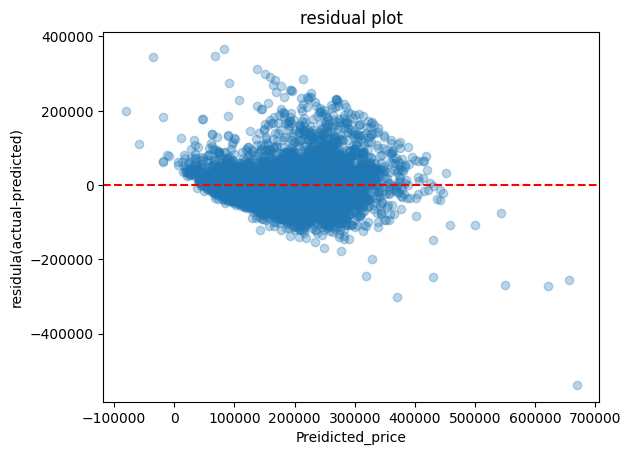

In [123]:
import matplotlib.pyplot as plt
residual = val_y - val_predictions
plt.scatter(val_predictions,residual,alpha=0.3)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Preidicted_price')
plt.ylabel('residula(actual-predicted)')
plt.title('residual plot')
plt.show()

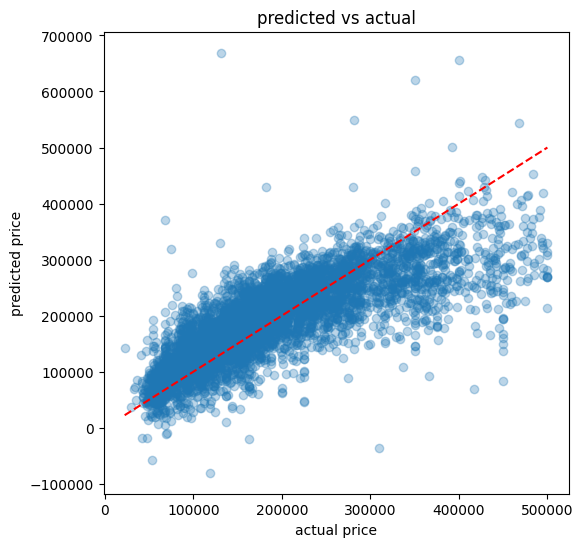

In [125]:
plt.figure(figsize=(6,6))
plt.scatter(val_y,val_predictions,alpha=0.3)
plt.plot([val_y.min(),val_y.max()],[val_y.min(),val_y.max()],'r--')
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.title('predicted vs actual')
plt.show()

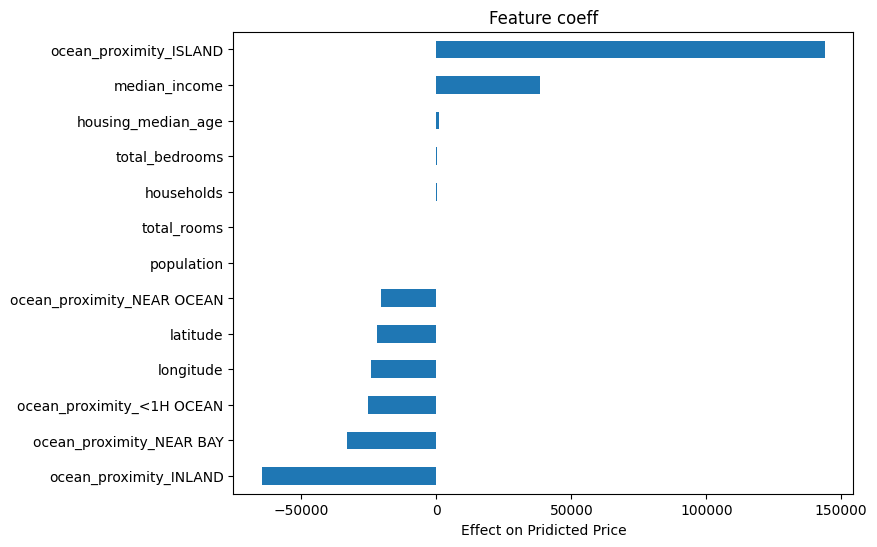

In [128]:
coeffs =pd.Series(model.coef_,index=train_X.columns).sort_values()
coeffs.plot(kind='barh',figsize=(8,6))
plt.title('Feature coeff')
plt.xlabel('Effect on Pridicted Price')
plt.show()

In [129]:
val_predictions = model.predict(val_X)
mae = mean_absolute_error(val_y, val_predictions)
r2 = r2_score(val_y, val_predictions)
print("MAE:", mae)
print("R^2:", r2)

MAE: 44835.888437857146
R^2: 0.6064028900866548
